# **Video Game Sales Analysis**

## 🗂️ **Project Summary**  

This Data Analysis notebook analyses pizza sales:

Profile and clean the data.

Explored distributions (revenue, margin, unit price), product/channel/region breakdowns, and customer segments.

Charted monthly and yearly sales patterns, highlighting recurring surges and dips.

Identified extreme transactions at both ends of the revenue and unit-price spectra.

Assessed relationships between key metrics and clustered customers by revenue vs. profit margin.

## ❓ **Problem Statement**  

Analyze the 2021–2025 sales data.

## 🎯 **Objective**

Deliver actionable insights from the company's 2021–2025 sales data to:

- Identify top-performing products, channels, and regions driving revenue and profit  
- Uncover trends and anomalies for optimized planning   
- Inform pricing, promotion, and market-expansion strategies  

These findings will guide the design of a Tableau dashboard to support strategic decision-making and sustainable growth.

# **📥 Setup & Configuration**

In [1]:
# 📘 IMPORT LIBRARIES

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure notebook display
%matplotlib inline
sns.set_style("whitegrid")    # clean seaborn style
plt.rcParams['figure.figsize'] = (10, 6)   # default fig size

# **🔄 Data Ingestion**

In [2]:
# 📂 LOAD DATA

from datetime import date
from datetime import datetime

# Path to Excel workbook
file_path = f'C:/Users/dcoke/Documents/Project 2/pizzas.csv'
file_path2 = f'C:/Users/dcoke/Documents/Project 2/data_dictionary.csv'
file_path3 = f'C:/Users/dcoke/Documents/Project 2/order_details.csv'
file_path4 = f'C:/Users/dcoke/Documents/Project 2/orders.csv'
file_path5 = f'C:/Users/dcoke/Documents/Project 2/pizza_types.csv'

df_pizzas = pd.read_csv(file_path)
df_data_dict = pd.read_csv(file_path2)
df_order_details = pd.read_csv(file_path3)
df_orders = pd.read_csv(file_path4)
df_pizza_types = pd.read_csv(file_path5, encoding='unicode_escape')

# add cost to df_pizzas
df_pizzas['pizza_cost'] = .7 * df_pizzas['price']

# combine date and time for datetime type
df_orders['datetime'] = pd.to_datetime(df_orders['date'] + ' ' + df_orders['time'])

# print(df_pizzas.head())
# print(df_data_dict.head())
# print(df_order_details.head())
# print(df_orders.head())
# print(df_pizza_types.head())



# **🔍 Data Profiling / Initial Inspection**

In [3]:
# 🔍 SHAPE OVERVIEW
print(f"df_pizzas          shape: {df_pizzas.shape}      # Pizzas")
print(f"df_data_dict       shape: {df_data_dict.shape}  # Data Dictionary")
print(f"df_order_details   shape: {df_order_details.shape}   # Order Details")
print(f"df_orders          shape: {df_orders.shape}    # Orders")
print(f"df_pizza_types     shape: {df_pizza_types.shape}  # Pizza Types")


df_pizzas          shape: (96, 5)      # Pizzas
df_data_dict       shape: (15, 3)  # Data Dictionary
df_order_details   shape: (48620, 4)   # Order Details
df_orders          shape: (21350, 4)    # Orders
df_pizza_types     shape: (32, 4)  # Pizza Types


In [4]:
# 🔍 OVERVIEW OF DATAFRAMES
# -----------------------------------------
# Print first few rows for each sheet

print("\n— df_pizzas head —")
display(df_pizzas.head())
print()

print("\n— df_data_dict head —")
display(df_data_dict.head())
print()

print("\n— df_order_details head —")
display(df_order_details.head())
print()

print("\n— df_orders head —")
display(df_orders.head())
print()

print("\n— df_pizza_types head —")
display(df_pizza_types.head())
print()


— df_pizzas head —


,pizza_id,pizza_type_id,size,price,pizza_cost
0,bbq_ckn_s,bbq_ckn,S,12.75,8.925
1,bbq_ckn_m,bbq_ckn,M,16.75,11.725
2,bbq_ckn_l,bbq_ckn,L,20.75,14.525
3,cali_ckn_s,cali_ckn,S,12.75,8.925
4,cali_ckn_m,cali_ckn,M,16.75,11.725




— df_data_dict head —


,Table,Field,Description
0,orders,order_id,Unique identifier for each order placed by a t...
1,orders,date,Date the order was placed (entered into the sy...
2,orders,time,Time the order was placed (entered into the sy...
3,order_details,order_details_id,Unique identifier for each pizza placed within...
4,order_details,order_id,Foreign key that ties the details in each orde...




— df_order_details head —


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1




— df_orders head —


,order_id,date,time,datetime
0,1,2015-01-01,11:38:36,2015-01-01 11:38:36
1,2,2015-01-01,11:57:40,2015-01-01 11:57:40
2,3,2015-01-01,12:12:28,2015-01-01 12:12:28
3,4,2015-01-01,12:16:31,2015-01-01 12:16:31
4,5,2015-01-01,12:21:30,2015-01-01 12:21:30




— df_pizza_types head —


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


# **🔍 CHECK FOR DUPES IN SALES DATA**

In [5]:
# Checking duplicate values


# *🧹 Data Cleaning*

In [6]:
# Merge with Order Details
df = df_orders.merge(
    df_order_details,
    how='left',
    left_on='order_id',
    right_on='order_id'
)

# Merge with Pizzas
df = df.merge(
    df_pizzas,
    how='left',
    left_on='pizza_id',
    right_on='pizza_id'
)

df.head()

,order_id,date,time,datetime,order_details_id,pizza_id,quantity,pizza_type_id,size,price,pizza_cost
0,1,2015-01-01,11:38:36,2015-01-01 11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,9.275
1,2,2015-01-01,11:57:40,2015-01-01 11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,11.200
2,2,2015-01-01,11:57:40,2015-01-01 11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,12.950
3,2,2015-01-01,11:57:40,2015-01-01 11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,14.525
4,2,2015-01-01,11:57:40,2015-01-01 11:57:40,5,mexicana_m,1,mexicana,M,16.00,11.200


In [7]:
# Convert all column names to lowercase for consistency and easier access
df.columns = df.columns.str.lower()

# Display the updated list of column names
df.columns.values

<StringArray>
[        'order_id',             'date',             'time',
         'datetime', 'order_details_id',         'pizza_id',
         'quantity',    'pizza_type_id',             'size',
            'price',       'pizza_cost']
Length: 11, dtype: str

In [8]:
# DROP UNNECESSARY COLUMNS & RENAME FOR CLARITY (with Region)
# ------------------------------------------------------------------

# 1) List only the columns you want to KEEP, now including the broader 'region'
# cols_to_keep = [
#     'order_id',        # unique order ID

# ]

# Subset the DataFrame to only these columns
# df = df[cols_to_keep]

# 2) Rename to more Pythonic / self-explanatory names, including region
# df = df.rename(columns={

# })

# Display the cleaned DataFrame structure
# df.head()

In [9]:
# Check for missing values in each column of the dataset
df.isnull().sum()

order_id            0
date                0
time                0
datetime            0
order_details_id    0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
pizza_cost          0
dtype: int64

In [12]:
# Calculate total cost for each line item
df['order_price'] = df['quantity'] * df['price']

# Calc total cost for each line item
df['order_cost'] = df['quantity'] * df['pizza_cost']

# Calculate profit as revenue minus total_cost
df['profit'] = df['order_price'] - df['order_cost']

# Calculate profit margin as a percentage
df['profit_margin_pct'] = (df['profit'] / df['order_price']) * 100

# Extract full month name from order_date for labeling (e.g., 'January', 'February')
df['order_month_name'] = df['datetime'].dt.month_name()

# Extract month number from order_date for correct sorting (1–12)
df['order_month_num'] = df['datetime'].dt.month

# (Optional) Display the updated DataFrame
print(df)

       order_id        date      time            datetime  order_details_id  \
0             1  2015-01-01  11:38:36 2015-01-01 11:38:36                 1   
1             2  2015-01-01  11:57:40 2015-01-01 11:57:40                 2   
2             2  2015-01-01  11:57:40 2015-01-01 11:57:40                 3   
3             2  2015-01-01  11:57:40 2015-01-01 11:57:40                 4   
4             2  2015-01-01  11:57:40 2015-01-01 11:57:40                 5   
...         ...         ...       ...                 ...               ...   
48615     21348  2015-12-31  21:23:10 2015-12-31 21:23:10             48616   
48616     21348  2015-12-31  21:23:10 2015-12-31 21:23:10             48617   
48617     21348  2015-12-31  21:23:10 2015-12-31 21:23:10             48618   
48618     21349  2015-12-31  22:09:54 2015-12-31 22:09:54             48619   
48619     21350  2015-12-31  23:02:05 2015-12-31 23:02:05             48620   

            pizza_id  quantity pizza_type_id size  

# 📊SALES ANALYSIS

# Monthly Sales Trend Over Time

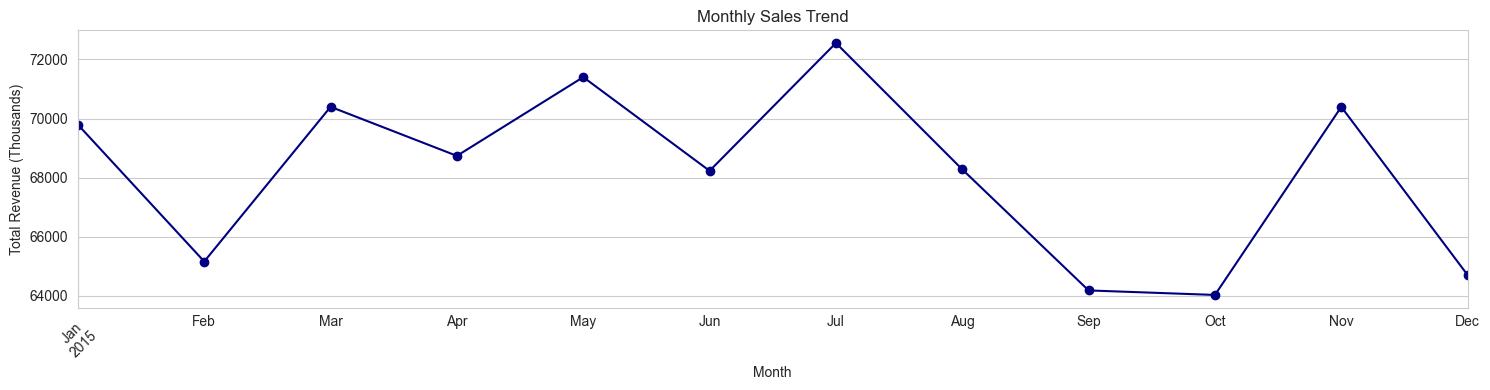

In [22]:
# Convert order_date to monthly period 
df['order_month'] = df['datetime'].dt.to_period('M')

# Calculate total revenue for each month
monthly_sales = df.groupby('order_month')['order_price'].sum()

# Set figure size for clarity
plt.figure(figsize=(15,4))

# Plot the monthly sales trend with circle markers and navy line
monthly_sales.plot(marker='o', color='navy')

# Scale y-axis values to millions for readability
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1:.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

# Add title and axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Thousands)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

# INSIGHTS ---
clear peaks in late spring to early summer (March–July) and troughs in Sep, Oct and Dec.



# Top 10 Products 

pizza_type_id
thai_ckn       42332.25
bbq_ckn        41683.00
cali_ckn       40166.50
classic_dlx    37631.50
spicy_ital     34163.50
southw_ckn     34081.75
ital_supr      32856.25
hawaiian       31561.75
four_cheese    31361.10
sicilian       30123.75
Name: price, dtype: float64


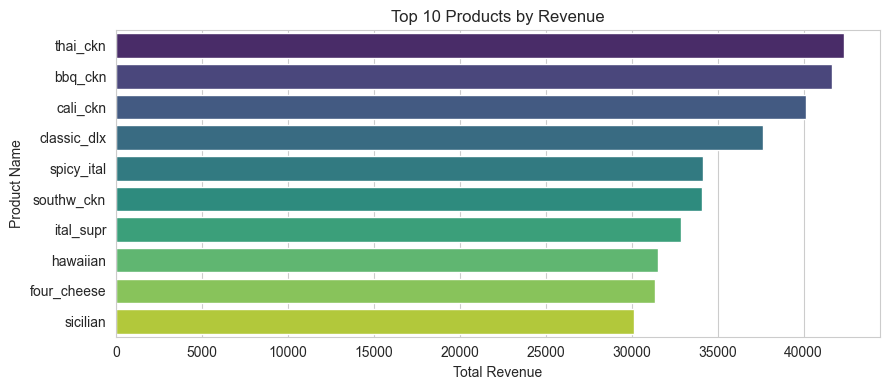

In [66]:
# Calculate total revenue for each product and convert values to millions
top_prod = df.groupby('pizza_type_id')['price'].sum() #/ 1_000_000

# Select the top 10 products by revenue
top_prod = top_prod.nlargest(10)
print(top_prod)

# Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    x=top_prod.values,    # X-axis: revenue values in millions
    y=top_prod.index,     # Y-axis: product names
    palette='viridis',     # Color palette for bars
    hue=top_prod.index,
    legend=False
)

# Add title and axis labels
plt.title('Top 10 Products by Revenue')  # Main title
plt.xlabel('Total Revenue')              # X-axis label
plt.ylabel('Product Name')                             # Y-axis label

# Adjust layout to prevent overlapping elements
plt.tight_layout()



# INSIGHTS ---


# Bottom 10 Products by Revenue

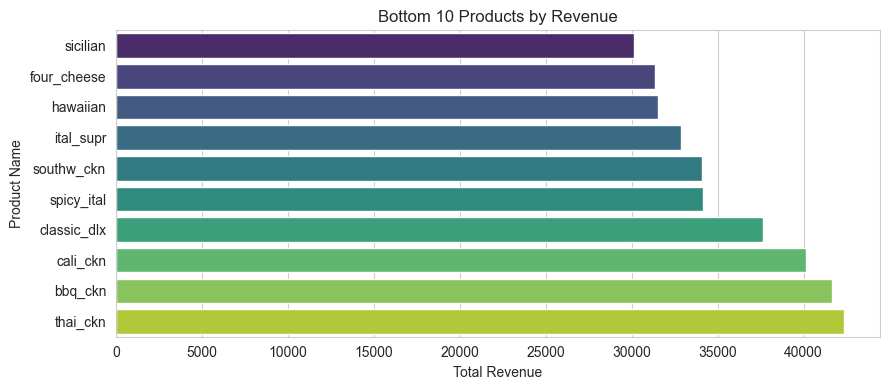

In [65]:
# Calculate total revenue for each product and convert values to millions
bottom_prod = df.groupby('pizza_type_id')['price'].sum() #/ 1_000_000

# Select the bottom 10 products by revenue
bottom_prod = top_prod.nsmallest(10)

# Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    x=bottom_prod.values,    # X-axis: revenue values in millions
    y=bottom_prod.index,     # Y-axis: product names
    palette='viridis',     # Color palette for bars
    hue=top_prod.index,
    legend=False
)

# Add title and axis labels
plt.title('Bottom 10 Products by Revenue')  # Main title
plt.xlabel('Total Revenue')              # X-axis label
plt.ylabel('Product Name')                             # Y-axis label

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# INSIGHTS ---


# Outliers - Largest Orders


In [73]:
#print(df)

#largest_orders = df.groupby('order_id')['price'].sum()['order_details_id'].count() #/ 1_000_000

largest_orders = df.groupby('order_id').agg(
    Total_Sum=('price', 'sum'),
    Total_Count=('order_id', 'count')
)

largest_orders = largest_orders.sort_values(by='Total_Sum', ascending=False)
largest_orders = largest_orders.head(20)

print(largest_orders)

#largest_orders = largest_orders.nlargest(10)

#print(largest_orders)



          Total_Sum  Total_Count
order_id                        
10760        349.90           21
18845        338.70           21
17464        261.00           15
14304        256.95           15
4482         246.95           14
13341        246.65           13
17943        244.35           14
11350        244.15           13
20710        244.00           15
21158        243.50           15
440          242.70           14
6169         242.50           13
740          241.95           13
9997         241.20           14
18280        240.75           15
13906        239.50           15
2675         238.00           14
7476         235.75           14
15045        235.60           13
12257        235.25           13
